In [12]:
import pandas as pd
import numpy as np
import geopandas as gpd
pd.set_option('display.max_columns', None)

In [13]:
df = gpd.read_parquet('/home/dataopske/Desktop/jav/data/processed/wards_full_gdf(with_spatial_gini).parquet')

In [14]:
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   gid                85 non-null     int64   
 1   pop2009            85 non-null     float64 
 2   county             85 non-null     object  
 3   subcounty          85 non-null     object  
 4   ward               85 non-null     object  
 5   uid                85 non-null     object  
 6   scuid              85 non-null     object  
 7   cuid               85 non-null     object  
 8   geometry           85 non-null     geometry
 9   population         85 non-null     float64 
 10  constituency       85 non-null     object  
 11  poverty_rate       85 non-null     float64 
 12  intersect_area     85 non-null     float64 
 13  ward_area          85 non-null     float64 
 14  coverage_ratio     85 non-null     float64 
 15  pop_served         85 non-null     float64 
 16  pc

- You want to include variables that describe how people live and are served — not identifiers or geometry.
Here’s a good starting subset for your case:

In [15]:
features = [
    "population",
    "poverty_rate",
    "pop_density",
    "coverage_ratio",
    "pct_access",
    "pop_served",
    "pop_not_served",
    "subcounty_gini"
]
df1 = df[features].copy()

> These combine social (poverty_rate, gini) and service access (coverage_ratio, pct_access, pop_served) dimensions — perfect for identifying underserved clusters.

In [16]:
from sklearn.preprocessing import StandardScaler
X = df1.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [17]:
from sklearn.cluster import KMeans
import pandas as pd

k = 4  # start with 4 clusters, you can tune later
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df1["cluster"] = kmeans.fit_predict(X_scaled)

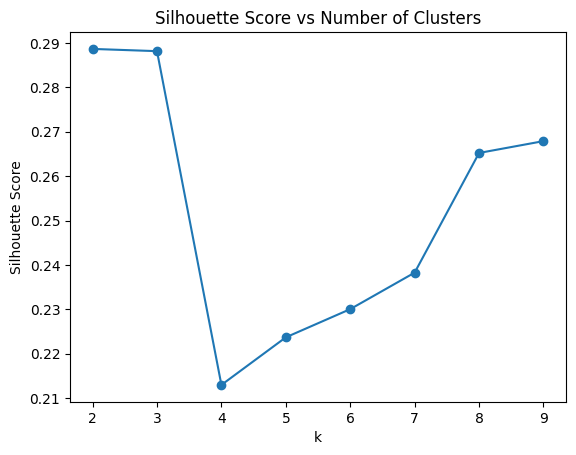

In [18]:
from sklearn.metrics import silhouette_score

scores = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

import matplotlib.pyplot as plt
plt.plot(range(2,10), scores, marker='o')
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()


In [19]:
df1

,population,poverty_rate,pop_density,coverage_ratio,pct_access,pop_served,pop_not_served,subcounty_gini,cluster
0,74177.992829,11.1,160022.77,0.883669,88.366913,65548.802666,8629.0,0.076869,0
1,92557.211478,13.8,23645.36,0.676181,67.618095,62585.423418,29972.0,0.268249,3
2,69612.843253,17.9,8509.21,0.980230,98.023042,68236.626485,1376.0,0.169643,0
3,142658.597296,12.7,8882.42,0.799057,79.905736,113992.402747,28666.0,0.088544,1
4,81906.408407,12.7,9061.06,0.967126,96.712582,79213.802060,2693.0,0.088544,0
...,...,...,...,...,...,...,...,...,...
80,48278.476367,14.5,136307.36,0.998561,99.856103,48209.005188,69.0,0.046200,0
81,68639.740358,14.5,158033.81,0.955866,95.586649,65610.427825,3029.0,0.046200,0
82,70822.385069,14.5,171700.90,1.000000,100.000000,70822.385069,0.0,0.046200,0
83,74514.220482,14.5,111517.37,0.999643,99.964329,74487.640457,27.0,0.046200,0


In [20]:
df["cluster"] = df1["cluster"].values


<Axes: >

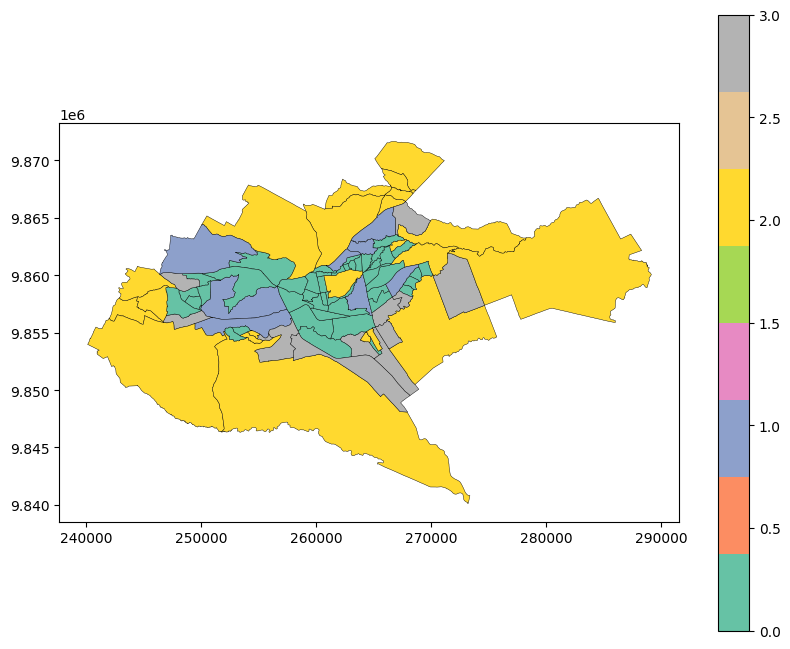

In [21]:
df.plot(
    column="cluster",
    cmap="Set2",
    legend=True,
    figsize=(10, 8),
    edgecolor="black",
    linewidth=0.3
)

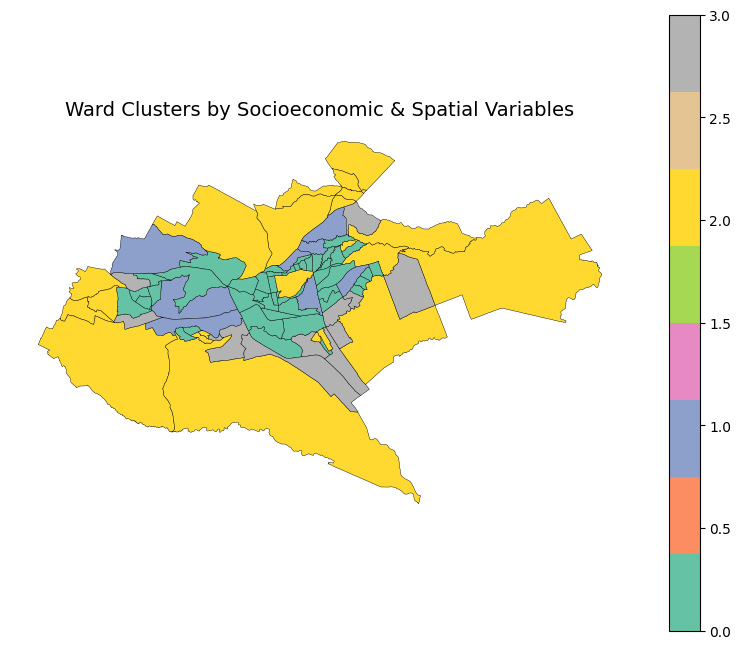

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
df.plot(column="cluster", cmap="Set2", legend=True, edgecolor="black", linewidth=0.3, ax=ax)
plt.title("Ward Clusters by Socioeconomic & Spatial Variables", fontsize=14)
plt.axis("off")
plt.savefig("/home/dataopske/Desktop/jav/data/training_output/ward_cluster_spatial.png", dpi=300, bbox_inches="tight")
plt.show()
